In [1]:
from scapy.layers.inet import IP, TCP, ICMP, UDP
from scapy.layers.l2 import Ether
from scapy.layers.dns import DNS, DNSQR
from scapy.all import sr1, srp

packet = IP() / TCP()
print(Ether() / packet)

p = Ether() / IP(dst="www.secdev.org") / TCP(flags="F")
print(p.summary())

print(p.dst)
print(p[IP].src)
print(p.sprintf("%Ether.src% > %Ether.dst%\n%IP.src% > %IP.dst%"))

print([p for p in IP(ttl=(1, 5)) / ICMP()])

print([p for p in IP() / TCP(dport=[22, 80, 443])])


Ether / IP / TCP 127.0.0.1:ftp_data > 127.0.0.1:http S
Ether / IP / TCP 192.168.11.4:ftp_data > Net("www.secdev.org/32"):http F
None
192.168.11.4
28:df:eb:d0:08:4f > None
192.168.11.4 > Net("www.secdev.org/32")
[<IP  frag=0 ttl=1 proto=icmp |<ICMP  |>>, <IP  frag=0 ttl=2 proto=icmp |<ICMP  |>>, <IP  frag=0 ttl=3 proto=icmp |<ICMP  |>>, <IP  frag=0 ttl=4 proto=icmp |<ICMP  |>>, <IP  frag=0 ttl=5 proto=icmp |<ICMP  |>>]
[<IP  frag=0 proto=tcp |<TCP  dport=ssh |>>, <IP  frag=0 proto=tcp |<TCP  dport=http |>>, <IP  frag=0 proto=tcp |<TCP  dport=https |>>]


In [2]:
p = sr1(IP(dst="8.8.8.8") / UDP() / DNS())
print(p[DNS].an)

Begin emission
.
Finished sending 1 packets

Received 2 packets, got 1 answers, remaining 0 packets
*[<DNSRR  rrname=b'www.example.com.' type=A cacheflush=0 rclass=IN ttl=300 rdata=104.18.27.120 |>, <DNSRR  rrname=b'www.example.com.' type=A cacheflush=0 rclass=IN ttl=300 rdata=104.18.26.120 |>]


In [3]:
r, u = srp(Ether() / IP(dst="8.8.8.8", ttl=(5, 10)) / UDP() / DNS())
print(r, u)

Begin emission

Finished sending 6 packets
******
Received 6 packets, got 6 answers, remaining 0 packets
<Results: TCP:0 UDP:0 ICMP:6 Other:0> <Unanswered: TCP:0 UDP:0 ICMP:0 Other:0>


In [4]:
print(r[0][0].summary())
print(r[0][1].summary())

Ether / IP / UDP / DNS Qry b'www.example.com.'
Ether / IP / ICMP / IPerror / UDPerror / DNS Qry b'www.example.com.' / Padding


In [5]:
print(r[0][1][ICMP])

ICMP / IPerror / UDPerror / DNS Qry b'www.example.com.' / Padding


In [6]:
from scapy.utils import wrpcap, rdpcap

In [7]:
wrpcap("scapy.pcap", r)

In [8]:
wrpcap("scapy.pcap", r)

pcap_p = rdpcap("scapy.pcap")
print(pcap_p[0])

Ether / IP / UDP / DNS Qry b'www.example.com.'


In [9]:
print(pcap_p[0].command())

Ether(dst='4c:85:8a:33:c8:00', src='28:df:eb:d0:08:4f', type=2048)/IP(version=4, ihl=5, tos=0, len=61, id=1, flags=0, frag=0, ttl=5, proto=17, chksum=55795, src='192.168.11.4', dst='8.8.8.8')/UDP(sport=53, dport=53, len=41, chksum=55577)/DNS(id=0, qr=0, opcode=0, aa=0, tc=0, rd=1, ra=0, z=0, ad=0, cd=0, rcode=0, qdcount=1, ancount=0, nscount=0, arcount=0, qd=[DNSQR(qname=b'www.example.com.', qtype=1, unicastresponse=0, qclass=1)])


In [10]:
from scapy.all import sniff

In [11]:
s = sniff(count=2)
print(s)

<Sniffed: TCP:2 UDP:0 ICMP:0 Other:0>


In [12]:
print(sniff(count=2, prn=lambda p: p.summary()))

Ether / fe80::119e:63bc:b55a:bdef > ff02::16 (0) / IPv6ExtHdrHopByHop / ICMPv6MLReport2
Ether / IP / UDP 192.168.11.4:37341 > 239.255.255.250:1900 / Raw
<Sniffed: TCP:0 UDP:1 ICMP:0 Other:1>


In [13]:
from scapy.all import lsc

In [14]:
lsc()

IPID_count            : Identify IP id values classes in a list of packets
arp_mitm              : ARP MitM: poison 2 target's ARP cache
arpcachepoison        : Poison targets' ARP cache
arping                : Send ARP who-has requests to determine which hosts are up::
arpleak               : Exploit ARP leak flaws, like NetBSD-SA2017-002.
bind_layers           : Bind 2 layers on some specific fields' values.
bridge_and_sniff      : Forward traffic between interfaces if1 and if2, sniff and return
chexdump              : Build a per byte hexadecimal representation
computeNIGroupAddr    : Compute the NI group Address. Can take a FQDN as input parameter
connect_from_ip       : Open a TCP socket to a host:port while spoofing another IP.
corrupt_bits          : Flip a given percentage (at least one bit) or number of bits
corrupt_bytes         : Corrupt a given percentage (at least one byte) or number of bytes
dclocator             : Perform a DC Locator as per [MS-ADTS] sect 6.3.6 or RFC41

In [15]:
from scapy.all import arping

In [16]:
print(arping("192.168.46.0/24"))

Begin emission

Finished sending 256 packets

Received 0 packets, got 0 answers, remaining 256 packets
src  manuf  psrc
(<ARPing: TCP:0 UDP:0 ICMP:0 Other:0>, <Unanswered: TCP:0 UDP:0 ICMP:0 Other:256>)


In [17]:
arping("192.168.11.0/24")

Begin emission
*
Finished sending 256 packets
**
Received 3 packets, got 3 answers, remaining 253 packets
src                manuf    psrc        
4c:85:8a:33:c8:00  unknown  192.168.11.1
a2:b5:41:98:7f:7d  unknown  192.168.11.2
b6:2a:6d:c7:af:8d  unknown  192.168.11.3


(<ARPing: TCP:0 UDP:0 ICMP:0 Other:3>,
 <Unanswered: TCP:0 UDP:0 ICMP:0 Other:253>)

In [18]:
from scapy.all import srloop

In [19]:
ans, unans = srloop(IP(dst=["8.8.8.8", "8.8.4.4"]) / ICMP(), inter=.1, timeout=.1, count=100, verbose=False)

[[<matplotlib.lines.Line2D at 0x77f9773123d0>],

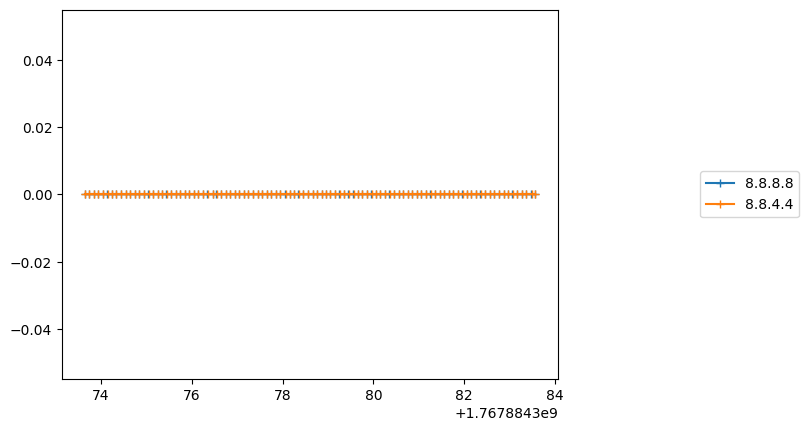

In [20]:
%matplotlib inline

ans.multiplot(lambda x, y: (y[IP].src, (y.time, y[IP].id)), plot_xy=True)

In [21]:
pkt = IP() / UDP() / DNS(qd=DNSQR())
print(str(pkt))

IP / UDP / DNS Qry b'www.example.com.'


In [22]:
from scapy.utils import hexdump

In [23]:
hexdump(pkt)

0000  45 00 00 3D 00 01 00 00 40 11 7C AD 7F 00 00 01  E..=....@.|.....
0010  7F 00 00 01 00 35 00 35 00 29 B6 D3 00 00 01 00  .....5.5.)......
0020  00 01 00 00 00 00 00 00 03 77 77 77 07 65 78 61  .........www.exa
0030  6D 70 6C 65 03 63 6F 6D 00 00 01 00 01           mple.com.....


In [24]:
pkt.show()

###[ IP ]###
  version   = 4
  ihl       = None
  tos       = 0x0
  len       = None
  id        = 1
  flags     = 
  frag      = 0
  ttl       = 64
  proto     = udp
  chksum    = None
  src       = 127.0.0.1
  dst       = 127.0.0.1
  \options   \
###[ UDP ]###
     sport     = domain
     dport     = domain
     len       = None
     chksum    = None
###[ DNS ]###
        id        = 0
        qr        = 0
        opcode    = QUERY
        aa        = 0
        tc        = 0
        rd        = 1
        ra        = 0
        z         = 0
        ad        = 0
        cd        = 0
        rcode     = ok
        qdcount   = None
        ancount   = None
        nscount   = None
        arcount   = None
        \qd        \
         |###[ DNS Question Record ]###
         |  qname     = b'www.example.com.'
         |  qtype     = A
         |  unicastresponse= 0
         |  qclass    = IN
        \an        \
        \ns        \
        \ar        \



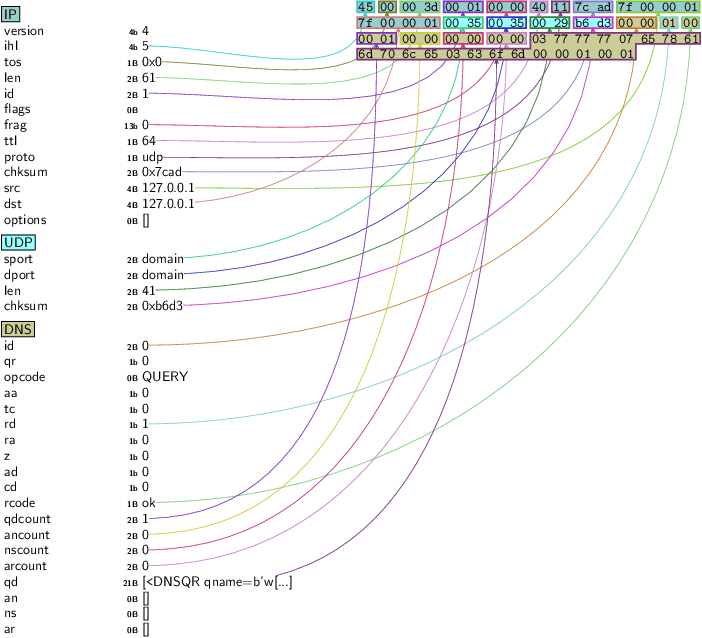

In [25]:
pkt.canvas_dump()

In [26]:
from scapy.all import traceroute

In [27]:
ans, unans = traceroute('www.secdev.org', maxttl=15)

Begin emission
******
Finished sending 15 packets
**
Received 8 packets, got 8 answers, remaining 7 packets
   217.25.178.5:tcp80 
1  192.168.11.1    11 
2  125.204.186.196 11 
3  125.204.186.237 11 
4  125.203.199.53  11 
5  125.201.248.93  11 
6  125.201.248.61  11 
13 129.250.2.176   11 
14 129.250.3.91    11 


In [31]:
ans.world_trace()

ERROR: Cannot import the geolite2 CITY database.
Download it from http://dev.maxmind.com/geoip/geoip2/geolite2/ then set its path to conf.geoip_city


[]